In [1]:
pip install tensorflow

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


## Importing Libraries 

In [5]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D
from tensorflow.keras.layers import Flatten, Dense, Dropout

## Load Dataset

In [6]:
(x_train,y_train),(x_test,y_test)=tf.keras.datasets.mnist.load_data()

## Display Images

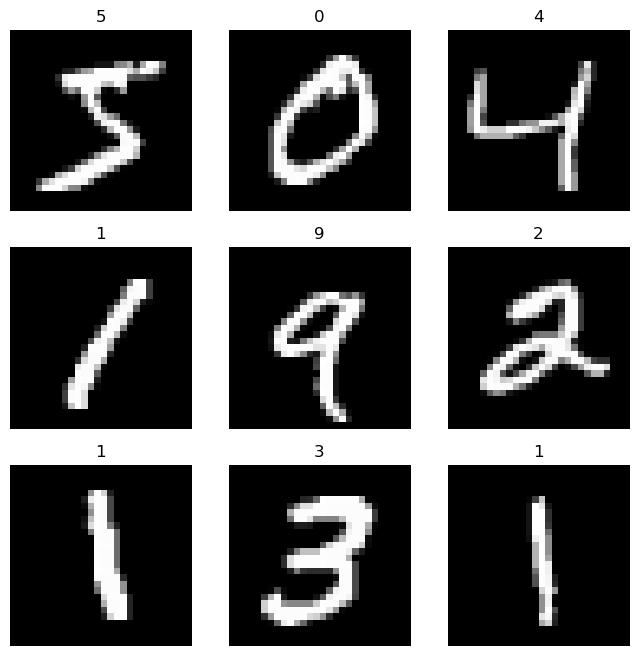

In [7]:
plt.figure(figsize=(8,8))

for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(x_train[i],cmap="gray")
    plt.title(y_train[i])
    plt.axis("off")

plt.show()

## Preprocessing

In [8]:
x_train=x_train.astype("float32")/255
x_test=x_test.astype("float32")/255

x_train=x_train.reshape(-1,28,28,1)
x_test=x_test.reshape(-1,28,28,1)

## CNN Model

In [10]:
model=Sequential([

Conv2D(32,(3,3),activation='relu',input_shape=(28,28,1)),
MaxPooling2D(2,2),

Conv2D(64,(3,3),activation='relu'),
MaxPooling2D(2,2),

Flatten(),

Dense(128,activation='relu'),
Dropout(0.5),

Dense(10,activation='softmax')

])

C:\Users\sharm\AppData\Roaming\Python\Python313\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


## Compile

In [11]:
model.compile(
optimizer='adam',
loss='sparse_categorical_crossentropy',
metrics=['accuracy']
)

## Train 

In [12]:
history=model.fit(
x_train,
y_train,
epochs=10,
validation_split=0.2,
batch_size=64
)

Epoch 1/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 14s 12ms/step - accuracy: 0.5564 - loss: 1.2936 - val_accuracy: 0.8754 - val_loss: 0.4405
Epoch 2/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 12s 16ms/step - accuracy: 0.8181 - loss: 0.5778 - val_accuracy: 0.9155 - val_loss: 0.2958
Epoch 3/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 8s 10ms/step - accuracy: 0.8548 - loss: 0.4596 - val_accuracy: 0.9322 - val_loss: 0.2315
Epoch 4/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 12s 16ms/step - accuracy: 0.8800 - loss: 0.3927 - val_accuracy: 0.9433 - val_loss: 0.1916
Epoch 5/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 13s 17ms/step - accuracy: 0.8983 - loss: 0.3298 - val_accuracy: 0.9496 - val_loss: 0.1693
Epoch 6/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 27s 25ms/step - accuracy: 0.9086 - loss: 0.2953 - val_accuracy: 0.9559 - val_loss: 0.1456
Epoch 7/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 9s 12ms/step - accuracy: 0.9179 - loss: 0.2696 - val_accuracy: 0.9613 - val_loss: 0.1276
Epoch 8/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 13s 17ms/step - accuracy: 0.9264 - loss: 0.2402 - va

## Evaluate

In [13]:
loss,accuracy=model.evaluate(x_test,y_test)

print("Accuracy:",accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9697 - loss: 0.0928
Accuracy: 0.9696999788284302


## Accuracy Graph

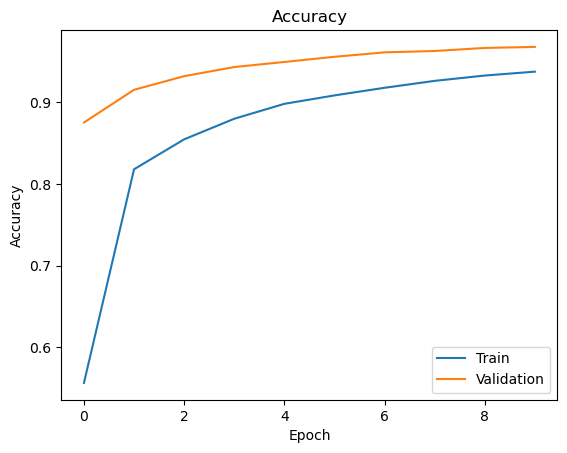

In [14]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title("Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.legend(["Train","Validation"])

plt.show()

## Loss Graph

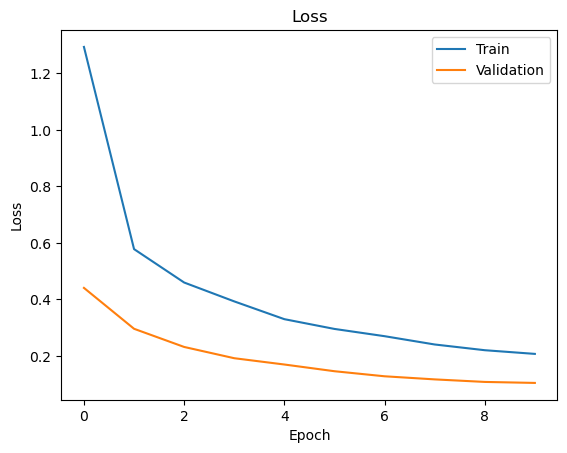

In [15]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.title("Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend(["Train","Validation"])

plt.show()

## Prediction

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
Predicted: 7
Actual: 7


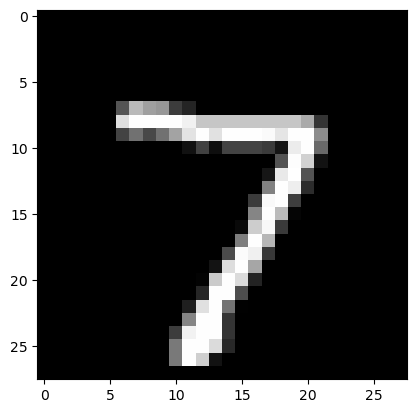

In [16]:
prediction=model.predict(x_test)

predicted=np.argmax(prediction[0])

print("Predicted:",predicted)
print("Actual:",y_test[0])

plt.imshow(x_test[0].reshape(28,28),cmap="gray")
plt.show()

## Save Model

In [17]:
model.save("handwritten_character_model.h5")